In [ ]:
import importlib.util

if importlib.util.find_spec('nest_asyncio') is None:
    print('Installing nest_asnycio')
    %pip install nest_asyncio
if importlib.util.find_spec('bleak') is None:
    print('Installing bleak')
    %pip install bleak

import nest_asyncio
nest_asyncio.apply()

import asyncio
import movesense as ms
import matplotlib.pyplot as plt



# DEVICE SETTINGS

ADDRESS = "0C:8C:DC:3C:9D:19" # Movesense address

# SUBSCRIBTION SETTINGS
# Refer to API for samplerates
# https://movesense.com/docs/esw/api_reference

SENSOR = ms.Sensor.IMU9

SAMPLERATE = 104 # Depends on sensor

REC_LENGTH = 60 # In seconds

START_DELAY = 5 # Wait N seconds after connecting

FILEPATH = "../../data/movesense/newrec/" # CSV save location (FOLDER MUST EXIST)

SAVE_TO_CSV = True # Option to disable saving data to a CSV.


device = ms.MovesenseClient(ADDRESS)

async def main():
    async with device as client:
        record = await client.subscribe(
            sensor=SENSOR, 
            samplerate=SAMPLERATE, 
            rec_length=REC_LENGTH, 
            start_delay=START_DELAY, 
            filepath=FILEPATH,
            save_to_csv=SAVE_TO_CSV
        )
    
        df = record.to_pandas()
        print(df.tail(5))
    
asyncio.run(main())

(ms1465) Connected
(ms1465) Recording starts in 5 seconds
(ms1465) Recording imu9 @ 104Hz
(ms1465) Recording complete
The path doesn't Exist. Saving to root folder instead
File created at: ./ms1465_imu9_2025-11-06_17-35-55.csv
      Timestamp   AccX   AccY   AccZ  GyroX  GyroY  GyroZ  MagnX  MagnY  MagnZ
6235        NaN -2.343  3.891  9.119 -2.355  3.671  9.115  71.19  15.33  27.44
6236   154199.0 -2.307  4.056  8.890 -1.151  5.250  7.935  86.52 -20.16  21.14
6237        NaN -1.910  4.685  8.222 -1.831  5.552  8.406  89.32 -27.37  21.00
6238        NaN -1.321  4.889  7.909 -2.218  5.391  9.009  79.73 -27.02  23.24
6239        NaN -0.888  4.685  7.617 -2.010  5.331  8.732  66.78 -23.45  21.35
(ms1465) Disconnected


✅ Suodatettu data tallennettu: ../../data/movesense/testeja/data_for_test(60s)_filtered.csv


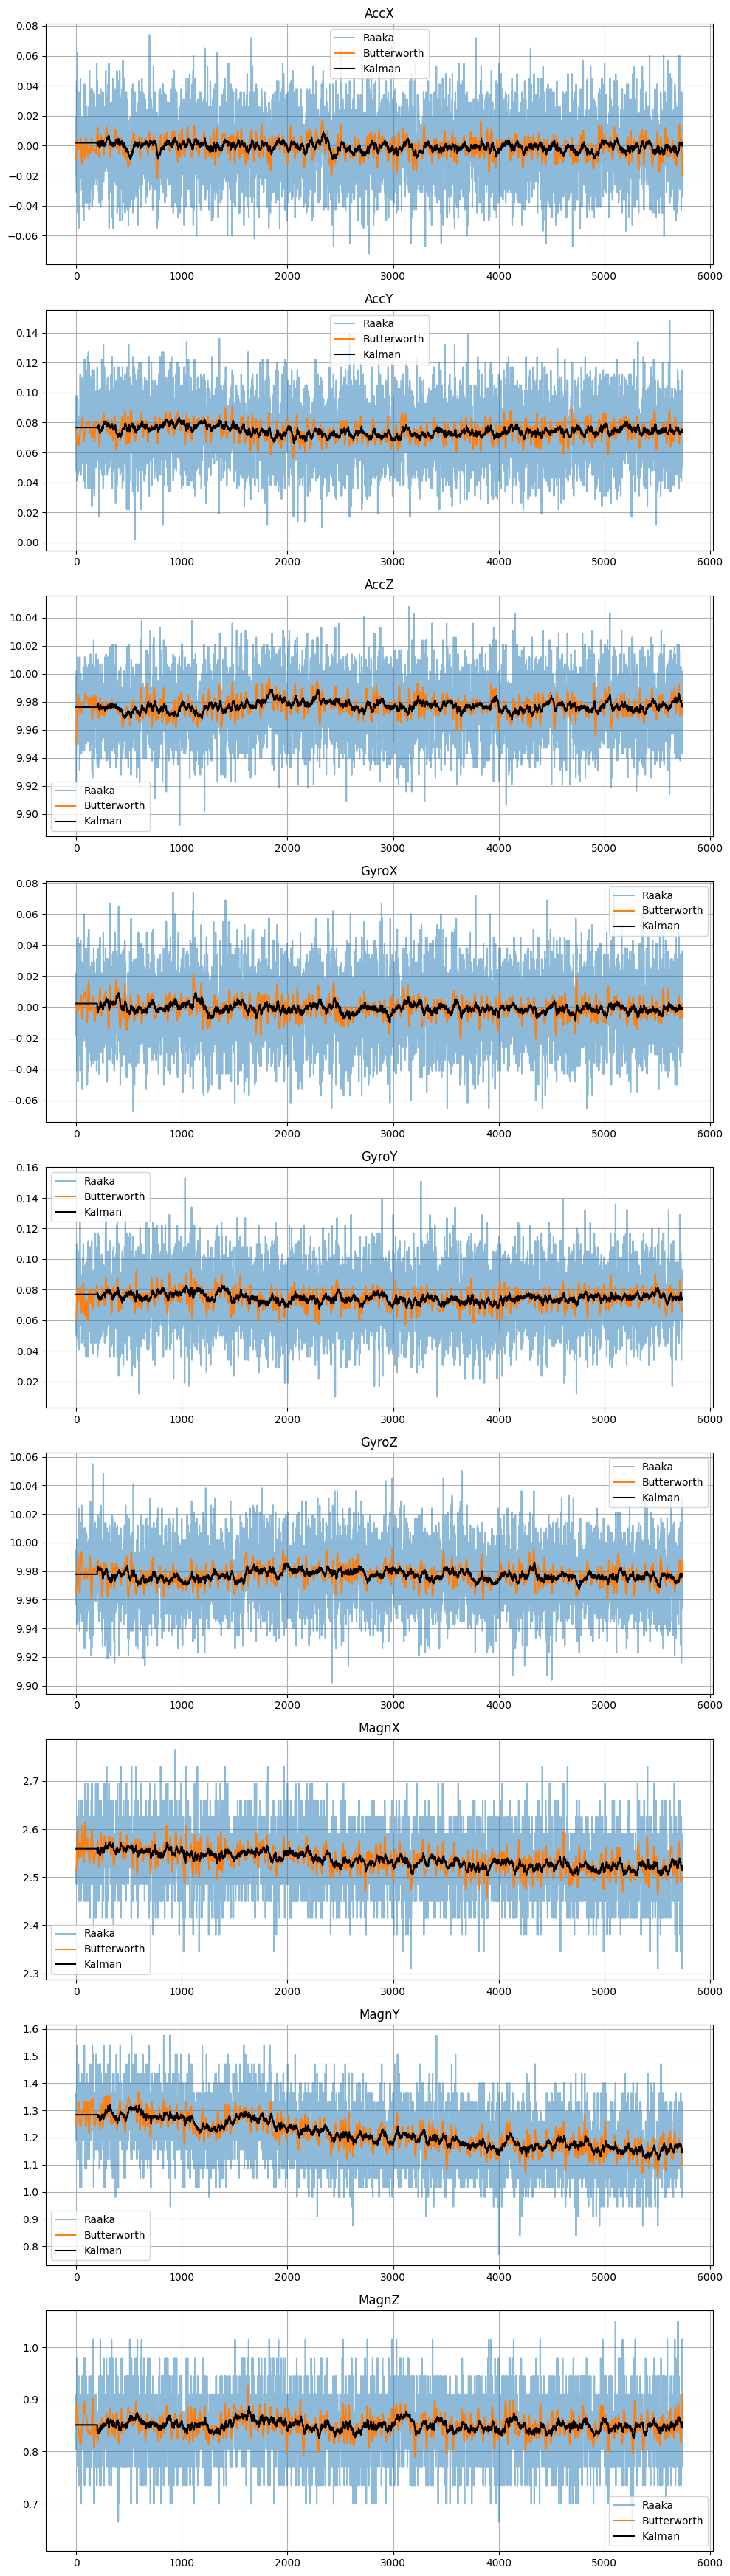

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 🔧 Простая реализация Калман-фильтра с "прогревом" ---
class SimpleKalman:
    def __init__(self, process_var=1e-5, meas_var=0.01, warmup=200):
        self.process_var = process_var      # дисперсия процесса (модельная)
        self.meas_var = meas_var            # дисперсия измерения (шум датчика)
        self.warmup = warmup                # количество точек для "прогрева"
        self.initialized = False

    def filter(self, data):
        estimates = []
        for i, measurement in enumerate(data):
            if not self.initialized:
                self.posteri_estimate = measurement
                self.posteri_error_estimate = 0.001  # <-- меньше неопределённость
                self.initialized = True

            # прогноз
            priori_estimate = self.posteri_estimate
            priori_error_estimate = self.posteri_error_estimate + self.process_var

            # усиление Калмана
            kalman_gain = priori_error_estimate / (priori_error_estimate + self.meas_var)

            # обновление оценки
            self.posteri_estimate = priori_estimate + kalman_gain * (measurement - priori_estimate)
            self.posteri_error_estimate = (1 - kalman_gain) * priori_error_estimate

            estimates.append(self.posteri_estimate)

        # "прогрев": первые warmup-точек считаем нестабильными → заменяем средним
        estimates = np.array(estimates)
        if len(estimates) > self.warmup:
            estimates[:self.warmup] = np.mean(estimates[self.warmup:self.warmup*2])
        return estimates


# --- 🔧 Улучшенный Butterworth low-pass с подавлением граничных эффектов ---
def butter_lowpass_filter(data, cutoff, fs, order=4, padlen=50):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    # паддинг: копируем крайние значения, чтобы избежать артефактов на старте
    padded = np.pad(data, (padlen, padlen), mode='edge')
    filtered = filtfilt(b, a, padded)
    return filtered[padlen:-padlen]


# --- 🔧 Основная функция обработки MoveSense данных ---
def process_imu_data(filename, fs=104, cutoff=5, order=4, save=True, plot=True, drop_n=500):
    df = pd.read_csv(filename)

    if len(df) <= drop_n:
        raise ValueError(f"Tiedosto on liian lyhyt ({len(df)} riviä) - ei voi poistaa {drop_n} riviä.")
    df = df.iloc[drop_n:].reset_index(drop=True)

    columns = ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','MagnX','MagnY','MagnZ']

    for col in columns:
        raw = df[col].values
        df[f'{col}_butter'] = butter_lowpass_filter(raw, cutoff, fs, order)
        kalman = SimpleKalman()
        df[f'{col}_kalman'] = kalman.filter(raw)

    if save:
        output_name = filename.replace('.csv', '_filtered.csv')
        df.to_csv(output_name, index=False)
        print(f"✅ Suodatettu data tallennettu: {output_name}")

    if plot:
        # Обрезаем первые 100–200 сэмплов на графике для чистоты
        view_start = 0
        fig, axes = plt.subplots(9, 1, figsize=(10, 35))
        for i, axis in enumerate(columns):
            axes[i].plot(df.index[view_start:], df[axis][view_start:], alpha=0.5, label='Raaka')
            axes[i].plot(df.index[view_start:], df[f'{axis}_butter'][view_start:], label='Butterworth')
            axes[i].plot(df.index[view_start:], df[f'{axis}_kalman'][view_start:], label='Kalman', color='black')
            axes[i].set_title(axis)
            axes[i].legend()
            axes[i].grid(True)
        plt.tight_layout()
        plt.show()

    return df


# --- 🔧 Пример вызова ---
if __name__ == "__main__":
    df_filtered = process_imu_data("../../data/movesense/testeja/data_for_test(60s).csv")


In [35]:
# calibration_process.py
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import dedent

G = 9.81


def read_files(file_list=None, orientation_col=None):
    """
    Если file_list содержит 6 файлов, каждый файл считается отдельной ориентацией.
    Ожидаемые имена файлов/ориентаций (в любом порядке): up, down, left, right, front, back
    Либо передать один файл с колонкой orientation (значения: up/down/left/right/front/back).
    """
    records = {}
    if file_list is None:
        raise ValueError("Передайте список файлов или путь к файлу с колонкой orientation.")
    # Если передали одиночный файл с колонкой orientation:
    if len(file_list) == 1 and orientation_col is not None:
        df = pd.read_csv(file_list[0])
        if orientation_col not in df.columns:
            raise ValueError(f"Колонка {orientation_col} не найдена в {file_list[0]}")
        for ori in ['up','down','left','right','front','back']:
            seg = df[df[orientation_col].astype(str).str.lower() == ori]
            if len(seg) > 0:
                records[ori] = seg[['AccX','AccY','AccZ']].dropna().reset_index(drop=True)
    else:
        # Ожидаем 6 файлов; пытаемся угадать ориентацию по имени файла
        for f in file_list:
            name = os.path.basename(f).lower()
            assigned = None
            for ori in ['up','down','left','right','front','back']:
                if ori in name:
                    assigned = ori
                    break
            if assigned is None:
                # если не нашли, журналим и используем имя файла как ключ
                assigned = os.path.splitext(os.path.basename(f))[0]
            records[assigned] = pd.read_csv(f)[['AccX','AccY','AccZ']].dropna().reset_index(drop=True)
    return records

def compute_stats(records, stat_len=None):
    """
    records: dict[orientation] -> DataFrame(AccX,AccY,AccZ)
    stat_len: как много первых N точек использовать из каждого файла (None = весь файл)
    """
    results = {}
    for ori, df in records.items():
        seg = df if stat_len is None else df.iloc[:stat_len]
        mean = seg.mean()
        std = seg.std()
        mag = np.sqrt((seg[['AccX','AccY','AccZ']]**2).sum(axis=1)).mean()
        results[ori] = {
            'n': len(seg),
            'AccX_mean': mean['AccX'], 'AccX_std': std['AccX'],
            'AccY_mean': mean['AccY'], 'AccY_std': std['AccY'],
            'AccZ_mean': mean['AccZ'], 'AccZ_std': std['AccZ'],
            'Mag_mean': mag
        }
    return pd.DataFrame(results).T

def compute_bias_scale(stats_df):
    """
    Предполагаем пары: up<->down => Z, left<->right => X, front<->back => Y
    bias = (pos + neg) / 2
    scale = (pos - neg) / (2*g)
    """
    def get_val(df, name):
        return df[name] if name in df.index else None

    axes = {'X':('left','right'),'Y':('front','back'),'Z':('up','down')}
    out = {}
    for ax, (pos, neg) in axes.items():
        if pos in stats_df.index and neg in stats_df.index:
            posm = stats_df.at[pos, f'Acc{ax}_mean']
            negm = stats_df.at[neg, f'Acc{ax}_mean']
            posstd = stats_df.at[pos, f'Acc{ax}_std']
            negstd = stats_df.at[neg, f'Acc{ax}_std']
            bias = (posm + negm) / 2.0
            # scale: (pos - neg) should be ~ 2*g -> scale factor ~ (pos-neg)/(2*g)
            scale = (posm - negm) / (2.0 * G)
            out[ax] = {
                'pos_mean': posm, 'pos_std': posstd,
                'neg_mean': negm, 'neg_std': negstd,
                'bias': bias, 'scale': scale
            }
        else:
            out[ax] = {'error': f"missing pair {pos}/{neg}"}
    return pd.DataFrame(out).T

def compute_gyro_bias(file_list, stat_len=200, out_prefix="gyro_bias"):
    """
    Вычисление bias гироскопа по первым stat_len отсчётам из каждого файла.
    """
    results = []
    for f in file_list:
        name = f.split("/")[-1].replace(".csv", "")
        df = pd.read_csv(f)
        seg = df[['GyroX','GyroY','GyroZ']].iloc[:stat_len]
        means = seg.mean()
        stds = seg.std()
        results.append({
            'file': name,
            'GyroX_mean': means['GyroX'],
            'GyroY_mean': means['GyroY'],
            'GyroZ_mean': means['GyroZ'],
            'GyroX_std': stds['GyroX'],
            'GyroY_std': stds['GyroY'],
            'GyroZ_std': stds['GyroZ']
        })
    res_df = pd.DataFrame(results)
    # Средний bias по всем ориентациям:
    avg_bias = res_df[['GyroX_mean','GyroY_mean','GyroZ_mean']].mean()
    print("\n=== Gyroscope static bias summary ===")
    print(res_df.round(5))
    print("\nMean bias across all files:")
    print(avg_bias.round(5))
    res_df.to_csv(out_prefix + ".csv", index=False)

    # Заключение
    limit = 0.1  # °/s, можно скорректировать по необходимости
    print("\nEvaluation:")
    for axis in ['X','Y','Z']:
        val = avg_bias[f'Gyro{axis}_mean']
        status = "OK ✅" if abs(val) < limit else "High bias ⚠️"
        print(f"Gyro{axis}: {val:.3f} °/s → {status}")

    print(f"\nSaved results to {out_prefix}.csv")
    return avg_bias, res_df


def save_report(stats_df, bs_df, out_prefix='calib_result'):
    stats_df.to_csv(out_prefix + '_stationary_stats.csv')
    bs_df.to_csv(out_prefix + '_bias_scale.csv')
    # Простой график: means per orientation
    fig, axs = plt.subplots(3,1, figsize=(8,10))
    for i, axis in enumerate(['AccX','AccY','AccZ']):
        means = [stats_df.at[ori, f'{axis}_mean'] if ori in stats_df.index else np.nan for ori in stats_df.index]
        axs[i].bar(range(len(stats_df.index)), means)
        axs[i].set_xticks(range(len(stats_df.index)))
        axs[i].set_xticklabels(stats_df.index, rotation=45)
        axs[i].set_ylabel(axis + ' mean (m/s^2)')
        axs[i].grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(out_prefix + '_means.png', dpi=150)
    plt.close(fig)
    print("Saved:", out_prefix + '_stationary_stats.csv,', out_prefix + '_bias_scale.csv,', out_prefix + '_means.png')

def main(files, orientation_col=None, stat_len=200, out_prefix='calib_result'):
    recs = read_files(files, orientation_col=orientation_col)
    if len(recs) < 6:
        print("Warning: detected <6 orientations. Found:", list(recs.keys()))
    stats = compute_stats(recs, stat_len=stat_len)
    bs = compute_bias_scale(stats)
    print("\n=== Stationary stats (sample) ===")
    print(stats.round(4))
    print("\n=== Bias & Scale per axis ===")
    print(bs.round(6))
    save_report(stats, bs, out_prefix=out_prefix)
    return stats, bs

if __name__ == '__main__':
    

    stats, bs = main([
        "../../data/movesense/calib/filtered/up(calib-1).csv",
        "../../data/movesense/calib/filtered/down(calib-2).csv",
        "../../data/movesense/calib/filtered/right(calib-3).csv",
        "../../data/movesense/calib/filtered/left(calib-4).csv",
        "../../data/movesense/calib/filtered/back(calib-5).csv",
        "../../data/movesense/calib/filtered/front(calib-6).csv",
    ], out_prefix="calib_movesense_v1")

    avg_bias, gyro_table = compute_gyro_bias([
        "../../data/movesense/calib/filtered/up(calib-1).csv",
        "../../data/movesense/calib/filtered/down(calib-2).csv",
        "../../data/movesense/calib/filtered/right(calib-3).csv",
        "../../data/movesense/calib/filtered/left(calib-4).csv",
        "../../data/movesense/calib/filtered/back(calib-5).csv",
        "../../data/movesense/calib/filtered/front(calib-6).csv",
    ], stat_len=200, out_prefix="gyro_bias_movesense_v1")


     # === Save calibration parameters (JSON, like magnetometer) ===
    import json

    acc_params = {
        "bias": {
            "X": float(bs.loc['X', 'bias']),
            "Y": float(bs.loc['Y', 'bias']),
            "Z": float(bs.loc['Z', 'bias'])
        },
        "scale": {
            "X": float(bs.loc['X', 'scale']),
            "Y": float(bs.loc['Y', 'scale']),
            "Z": float(bs.loc['Z', 'scale'])
        },
        "source_file": [
            "../../data/movesense/calib/filtered/up(calib-1).csv",
            "../../data/movesense/calib/filtered/down(calib-2).csv",
            "../../data/movesense/calib/filtered/right(calib-3).csv",
            "../../data/movesense/calib/filtered/left(calib-4).csv",
            "../../data/movesense/calib/filtered/back(calib-5).csv",
            "../../data/movesense/calib/filtered/front(calib-6).csv"
        ]
    }

    gyro_params = {
        "bias": {
            "X": float(avg_bias['GyroX_mean']),
            "Y": float(avg_bias['GyroY_mean']),
            "Z": float(avg_bias['GyroZ_mean'])
        },
        "source_file": [
            "../../data/movesense/calib/filtered/up(calib-1).csv",
            "../../data/movesense/calib/filtered/down(calib-2).csv",
            "../../data/movesense/calib/filtered/right(calib-3).csv",
            "../../data/movesense/calib/filtered/left(calib-4).csv",
            "../../data/movesense/calib/filtered/back(calib-5).csv",
            "../../data/movesense/calib/filtered/front(calib-6).csv"
        ]
    }

    with open("accelerometer_calibrated_params.json", "w") as f:
        json.dump(acc_params, f, indent=4)

    with open("gyroscope_calibrated_params.json", "w") as f:
        json.dump(gyro_params, f, indent=4)

    print("\n✅ Saved accelerometer calibration → accelerometer_calibrated_params.json")
    print("✅ Saved gyroscope calibration → gyroscope_calibrated_params.json")


=== Stationary stats (sample) ===
           n  AccX_mean  AccX_std  AccY_mean  AccY_std  AccZ_mean  AccZ_std  \
up     200.0    -0.0228    0.0211     0.0427    0.0193     9.9830    0.0201   
down   200.0    -0.0488    0.0202    -0.0610    0.0197    -9.9227    0.0198   
right  200.0    -9.9017    0.0222    -0.0743    0.0201    -0.0837    0.0197   
left   200.0     9.8696    0.0190    -0.5872    0.0190    -0.1183    0.0206   
back   200.0    -0.1093    0.0213    -9.9382    0.0190     0.0461    0.0265   
front  200.0     0.7998    0.0888     9.8308    0.0672    -0.3661    0.0476   

       Mag_mean  
up       9.9831  
down     9.9230  
right    9.9023  
left     9.8878  
back     9.9390  
front    9.8705  

=== Bias & Scale per axis ===
   pos_mean   pos_std  neg_mean   neg_std      bias     scale
X  9.869605  0.018954 -9.901660  0.022234 -0.016027  1.007710
Y  9.830755  0.067194 -9.938185  0.018992 -0.053715  1.007591
Z  9.982985  0.020053 -9.922675  0.019767  0.030155  1.014560
Saved:

Loaded 5740 samples from magn_data_test_last3_filtered.csv

=== Magnetometer calibration results ===
Hard-iron offset (bias): [-32.9478 -26.3945  14.02  ]
Soft-iron scale factors: [0.8073 0.9822 1.1762]

Mean |B| before: 140.04 µT
Mean |B| after:  147.62 µT


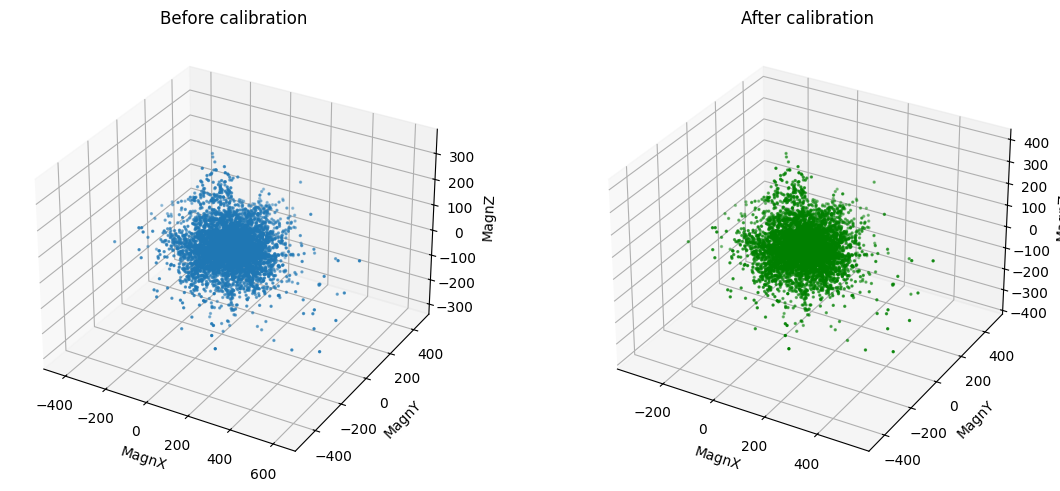


✅ Calibrated data saved to: magnetometer_calibrated.csv
✅ Calibration parameters saved to: magnetometer_calibrated_params.json


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
import json
import os

def fit_ellipsoid(x, y, z):
    """
    Подгонка эллипсоида под точки магнитного поля.
    Возвращает матрицу A и вектор b для уравнения:
    (p - b)^T * A * (p - b) = 1
    """
    D = np.column_stack([x * x, y * y, z * z, 2 * y * z, 2 * x * z, 2 * x * y, 2 * x, 2 * y, 2 * z, np.ones_like(x)])
    _, _, V = np.linalg.svd(D)
    coeff = V[-1, :]
    A = np.array([[coeff[0], coeff[5], coeff[4]],
                  [coeff[5], coeff[1], coeff[3]],
                  [coeff[4], coeff[3], coeff[2]]])
    b = -np.array([coeff[6], coeff[7], coeff[8]])
    offset = inv(A).dot(b)
    return A, offset

def calibrate_magnetometer(filename="magn_calib.csv", out_prefix="mag_calib_result"):
    df = pd.read_csv(filename)
    x, y, z = df['MagnX'], df['MagnY'], df['MagnZ']

    print(f"Loaded {len(df)} samples from {filename}")

    # 1️⃣ График до калибровки
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x, y, z, s=2)
    ax1.set_title("Before calibration")
    ax1.set_xlabel("MagnX"); ax1.set_ylabel("MagnY"); ax1.set_zlabel("MagnZ")

    # 2️⃣ Подгонка эллипсоида и вычисление коррекции
    A, offset = fit_ellipsoid(x, y, z)
    bias = offset
    A_inv = inv(A)
    scales = np.sqrt(1 / np.diag(A_inv) / np.mean(1 / np.diag(A_inv)))

    print("\n=== Magnetometer calibration results ===")
    print(f"Hard-iron offset (bias): {bias.round(4)}")
    print(f"Soft-iron scale factors: {scales.round(4)}")

    # 3️⃣ Применение коррекции
    mag_corr = np.column_stack([x - bias[0], y - bias[1], z - bias[2]]) * scales
    df[['MagnX_corr', 'MagnY_corr', 'MagnZ_corr']] = mag_corr

    # 4️⃣ Проверка нормы магнитного поля
    df['Mag_norm_raw'] = np.sqrt(x**2 + y**2 + z**2)
    df['Mag_norm_corr'] = np.sqrt(df['MagnX_corr']**2 + df['MagnY_corr']**2 + df['MagnZ_corr']**2)
    print(f"\nMean |B| before: {df['Mag_norm_raw'].mean():.2f} µT")
    print(f"Mean |B| after:  {df['Mag_norm_corr'].mean():.2f} µT")

    # 5️⃣ График после калибровки
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(df['MagnX_corr'], df['MagnY_corr'], df['MagnZ_corr'], s=2, color='green')
    ax2.set_title("After calibration")
    ax2.set_xlabel("MagnX"); ax2.set_ylabel("MagnY"); ax2.set_zlabel("MagnZ")
    plt.tight_layout()
    plt.show()

    # 6️⃣ Сохранение откалиброванных данных
    out_csv = f"{out_prefix}.csv"
    df.to_csv(out_csv, index=False)

    # 7️⃣ Сохранение параметров калибровки в JSON
    calib_params = {
        "hard_iron_bias": bias.round(6).tolist(),
        "soft_iron_scale": scales.round(6).tolist(),
        "mean_field_before_uT": round(df['Mag_norm_raw'].mean(), 3),
        "mean_field_after_uT": round(df['Mag_norm_corr'].mean(), 3),
        "source_file": os.path.basename(filename)
    }

    json_path = f"{out_prefix}_params.json"
    with open(json_path, 'w') as f:
        json.dump(calib_params, f, indent=4)

    print(f"\n✅ Calibrated data saved to: {out_csv}")
    print(f"✅ Calibration parameters saved to: {json_path}")

    return bias, scales, df


if __name__ == "__main__":
    calibrate_magnetometer("magn_data_test_last3_filtered.csv", out_prefix="magnetometer_calibrated")


In [23]:
import json
import os
from datetime import datetime

def combine_calibration_files(
    acc_json="accelerometer_calibrated_params.json",
    gyro_json="gyroscope_calibrated_params.json",
    mag_json="magnetometer_calibrated_params.json",
    out_json="movesense_calibration.json",
    out_py="movesense_calibration.py"
):
    """
    Объединяет три JSON-файла с калибровками (Acc, Gyro, Mag)
    в один json movesense_calibration.json и соответствующий .py файл.
    """
    combined = {
        "device": "MoveSense",
        "created_at": datetime.now().isoformat(timespec='seconds'),
        "sensors": {}
    }

    # Собираем данные из JSON
    for name, path in [("accelerometer", acc_json), ("gyroscope", gyro_json), ("magnetometer", mag_json)]:
        if os.path.exists(path):
            with open(path, "r") as f:
                combined["sensors"][name] = json.load(f)
        else:
            print(f"⚠️ Warning: {path} not found, skipping {name}")

    # --- Сохраняем JSON ---
    with open(out_json, "w") as f:
        json.dump(combined, f, indent=4)
    print(f"\n✅ Combined calibration saved to: {out_json}")

    # --- Создаём .py файл ---
    python_content = (
        "# This file was automatically generated on "
        f"{combined['created_at']}\n"
        "calibration_data = "
        + json.dumps(combined, indent=4)
        + "\n"
    )

    with open(out_py, "w") as f:
        f.write(python_content)
    print(f"✅ Python calibration module saved to: {out_py}")


# --- пример вызова (если всё в одной папке):
combine_calibration_files(
    acc_json="calib/params/accelerometer_calibrated_params.json",
    gyro_json="calib/params/gyroscope_calibrated_params.json",
    mag_json="calib/params/magnetometer_calibrated_params.json",
    out_json="calib/params/movesense_calibration.json",
    out_py="calib/params/movesense_calibration.py"
)



✅ Combined calibration saved to: calib/params/movesense_calibration.json
✅ Python calibration module saved to: calib/params/movesense_calibration.py
